<div class="alert alert-block alert-success">
# What is Regression?
</div>


<div class="alert alert-block alert-success">
Regression is a supervised learning technique used to:

Predict a continuous value

Find relationship between independent variable (X) and dependent variable (Y)

Example:

Predict house price

Predict salary

Predict temperature 
</div>

<div class="alert alert-block alert-success">
1️⃣ Linear Regression</div>

1️⃣ Simple Linear Regression

Only one independent variable (X)

One dependent variable (Y)

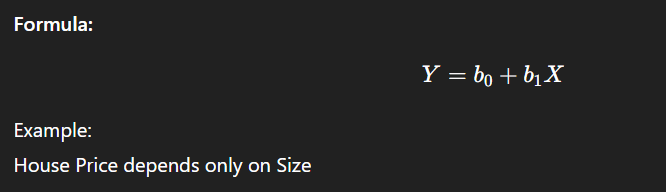

2️⃣ Multiple Linear Regression

More than one independent variable

One dependent variable

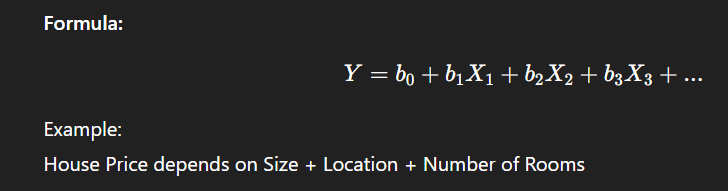

In [1]:
import matplotlib.offsetbox
from numpy import matrix
import numpy as np   #Used for numerical operations and working with arrays.
import pandas as pd  #Used for data manipulation and analysis.
import matplotlib.pyplot as plt  #Used for data visualization.
import seaborn as sns  #Used for data visualization.

from sklearn.datasets import fetch_openml   #Imports function to load datasets from OpenML.
from sklearn.model_selection import train_test_split   #Splits dataset into training and testing sets.
from sklearn.linear_model import LinearRegression      #Implements linear regression model.
from sklearn.metrics import mean_squared_error, r2_score #Evaluates model performance.
#Mean Squared Error (MSE) → Measures prediction error
#R² Score → Measures model accuracy
from sklearn.preprocessing import StandardScaler        #Used for feature scaling (normalizing data) and Makes mean = 0 and standard deviation = 1.

from statsmodels.stats.outliers_influence import variance_inflation_factor   #Used to check multicollinearity between independent variables.
from statsmodels.stats.stattools import durbin_watson    #Used to check whether residuals are independent (no autocorrelation).
import scipy.stats as stats                              #Used to perform statistical tests like checking normality of residuals (QQ plot).

In [2]:
# Load Dataset
boston=fetch_openml(name='boston', version=1, as_frame = True)
print(boston)
df=boston.frame
# boston → Variable that stores the complete dataset object.
# fetch_openml() → Function used to download dataset from OpenML.
# name='boston' → Specifies the Boston Housing dataset.
# version=1 → Loads version 1 of the dataset.
# as_frame=True → Returns data in Pandas DataFrame format instead of NumPy array.

{'data':         CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  \
0    0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0   
1    0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0   
2    0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0   
3    0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0   
4    0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0   
..       ...   ...    ...  ...    ...    ...   ...     ...  ..    ...   
501  0.06263   0.0  11.93    0  0.573  6.593  69.1  2.4786   1  273.0   
502  0.04527   0.0  11.93    0  0.573  6.120  76.7  2.2875   1  273.0   
503  0.06076   0.0  11.93    0  0.573  6.976  91.0  2.1675   1  273.0   
504  0.10959   0.0  11.93    0  0.573  6.794  89.3  2.3889   1  273.0   
505  0.04741   0.0  11.93    0  0.573  6.030  80.8  2.5050   1  273.0   

     PTRATIO       B  LSTAT  
0       15.3  396.90   4.98  
1       17.8  396.90   9.14  
2       17.8  392.83   4

In [3]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273.0,21.0,396.90,7.88,11.9


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 48.6 KB


In [6]:
df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [10]:
df.describe(include='all')

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506,506.000000,506.000000,506.000000,506.000000,506,506.000000,506.000000,506.000000,506.000000,506.000000
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,24,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,471,NaN,NaN,NaN,NaN,132,NaN,NaN,NaN,NaN,NaN
mean,3.613524,11.363636,11.136779,NaN,0.554695,6.284634,68.574901,3.795043,NaN,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,NaN,0.115878,0.702617,28.148861,2.105710,NaN,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,NaN,0.385000,3.561000,2.900000,1.129600,NaN,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,NaN,0.449000,5.885500,45.025000,2.100175,NaN,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,NaN,0.538000,6.208500,77.500000,3.207450,NaN,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,NaN,0.624000,6.623500,94.075000,5.188425,NaN,666.000000,20.200000,396.225000,16.955000,25.000000


In [11]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='str')

In [12]:
df.shape

(506, 14)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
#we can check the correlation
correlation_matrix=df.corr()
correlation_matrix

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


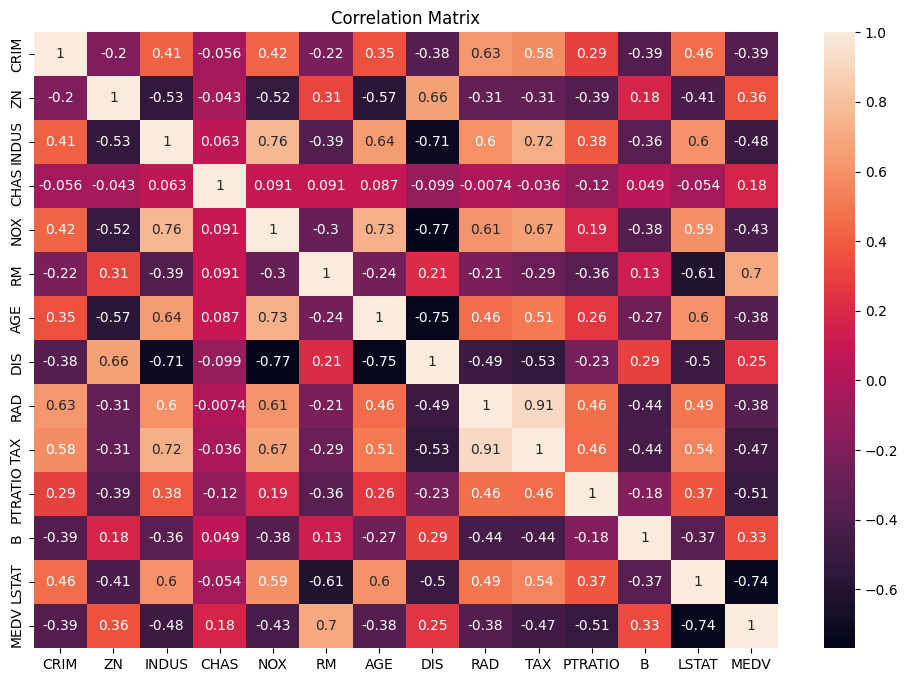

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix')
plt.show()

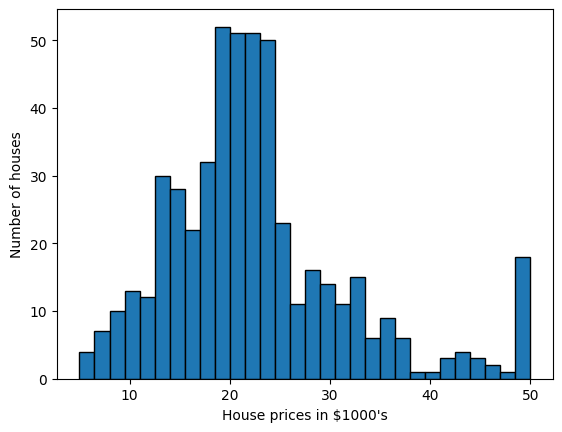

In [16]:
plt.hist(df['MEDV'] , bins=30, edgecolor='black')
plt.xlabel("House prices in $1000's")
plt.ylabel("Number of houses")
plt.show()


#it means that most of the houses are ranges from $20000 to $25000 , and few high rate houses are outliers are present

In [17]:
print("Kurtosis of MEDV:", df['MEDV'].kurt())

#it means outliers are present

Kurtosis of MEDV: 1.495196944165818


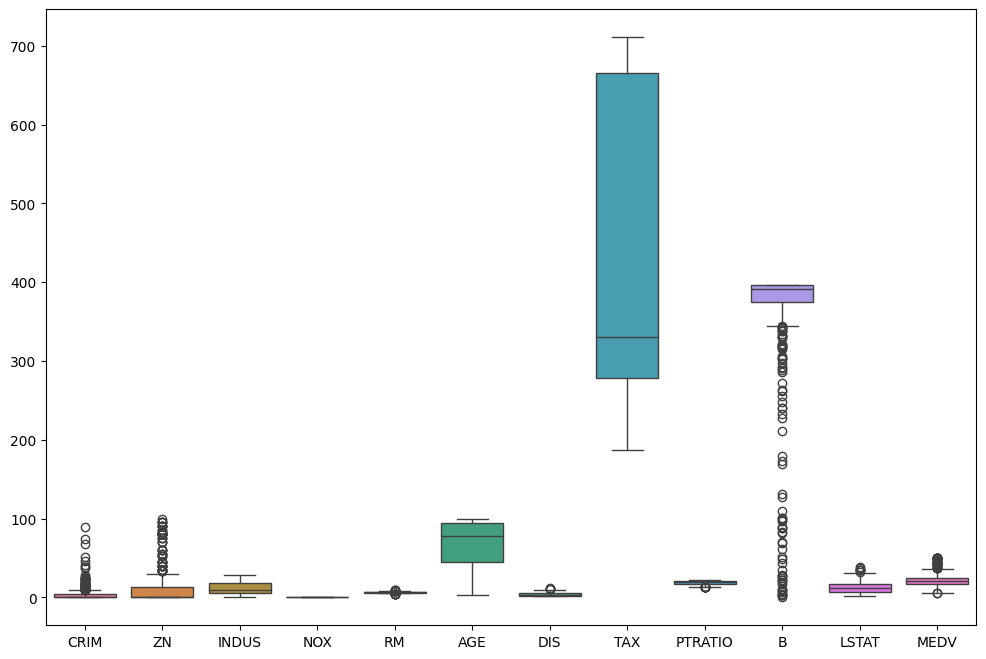

In [18]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.show()

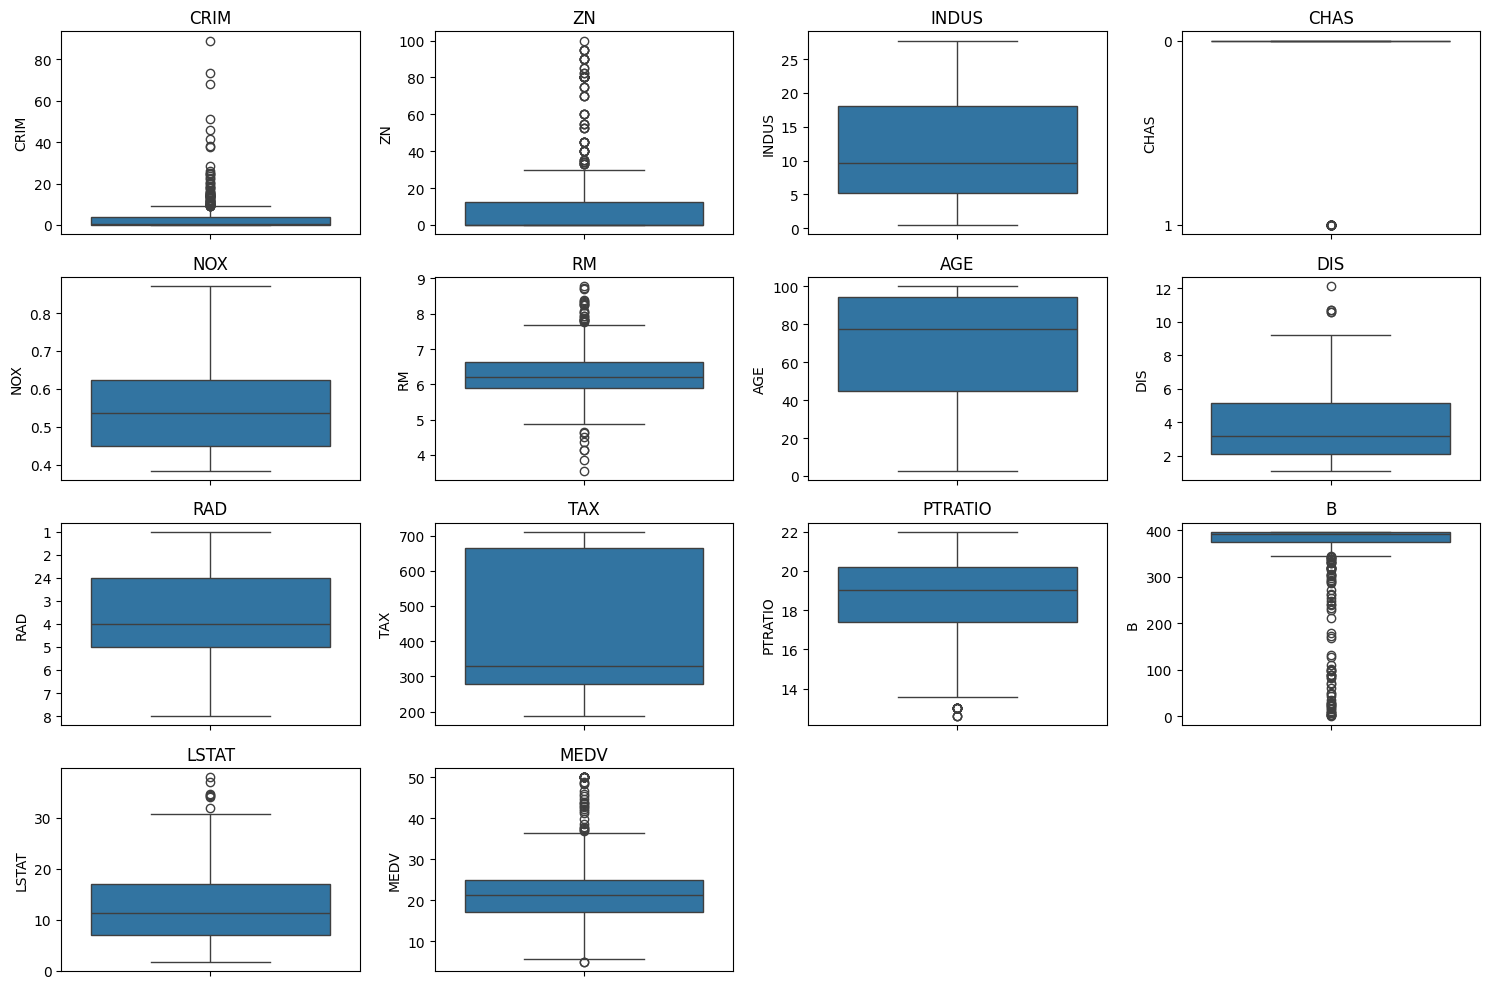

In [19]:
# Boxplots for outlier detection
plt.figure(figsize=(15,10))
for i, col in enumerate(df.columns,1):
    plt.subplot(4,4,i)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

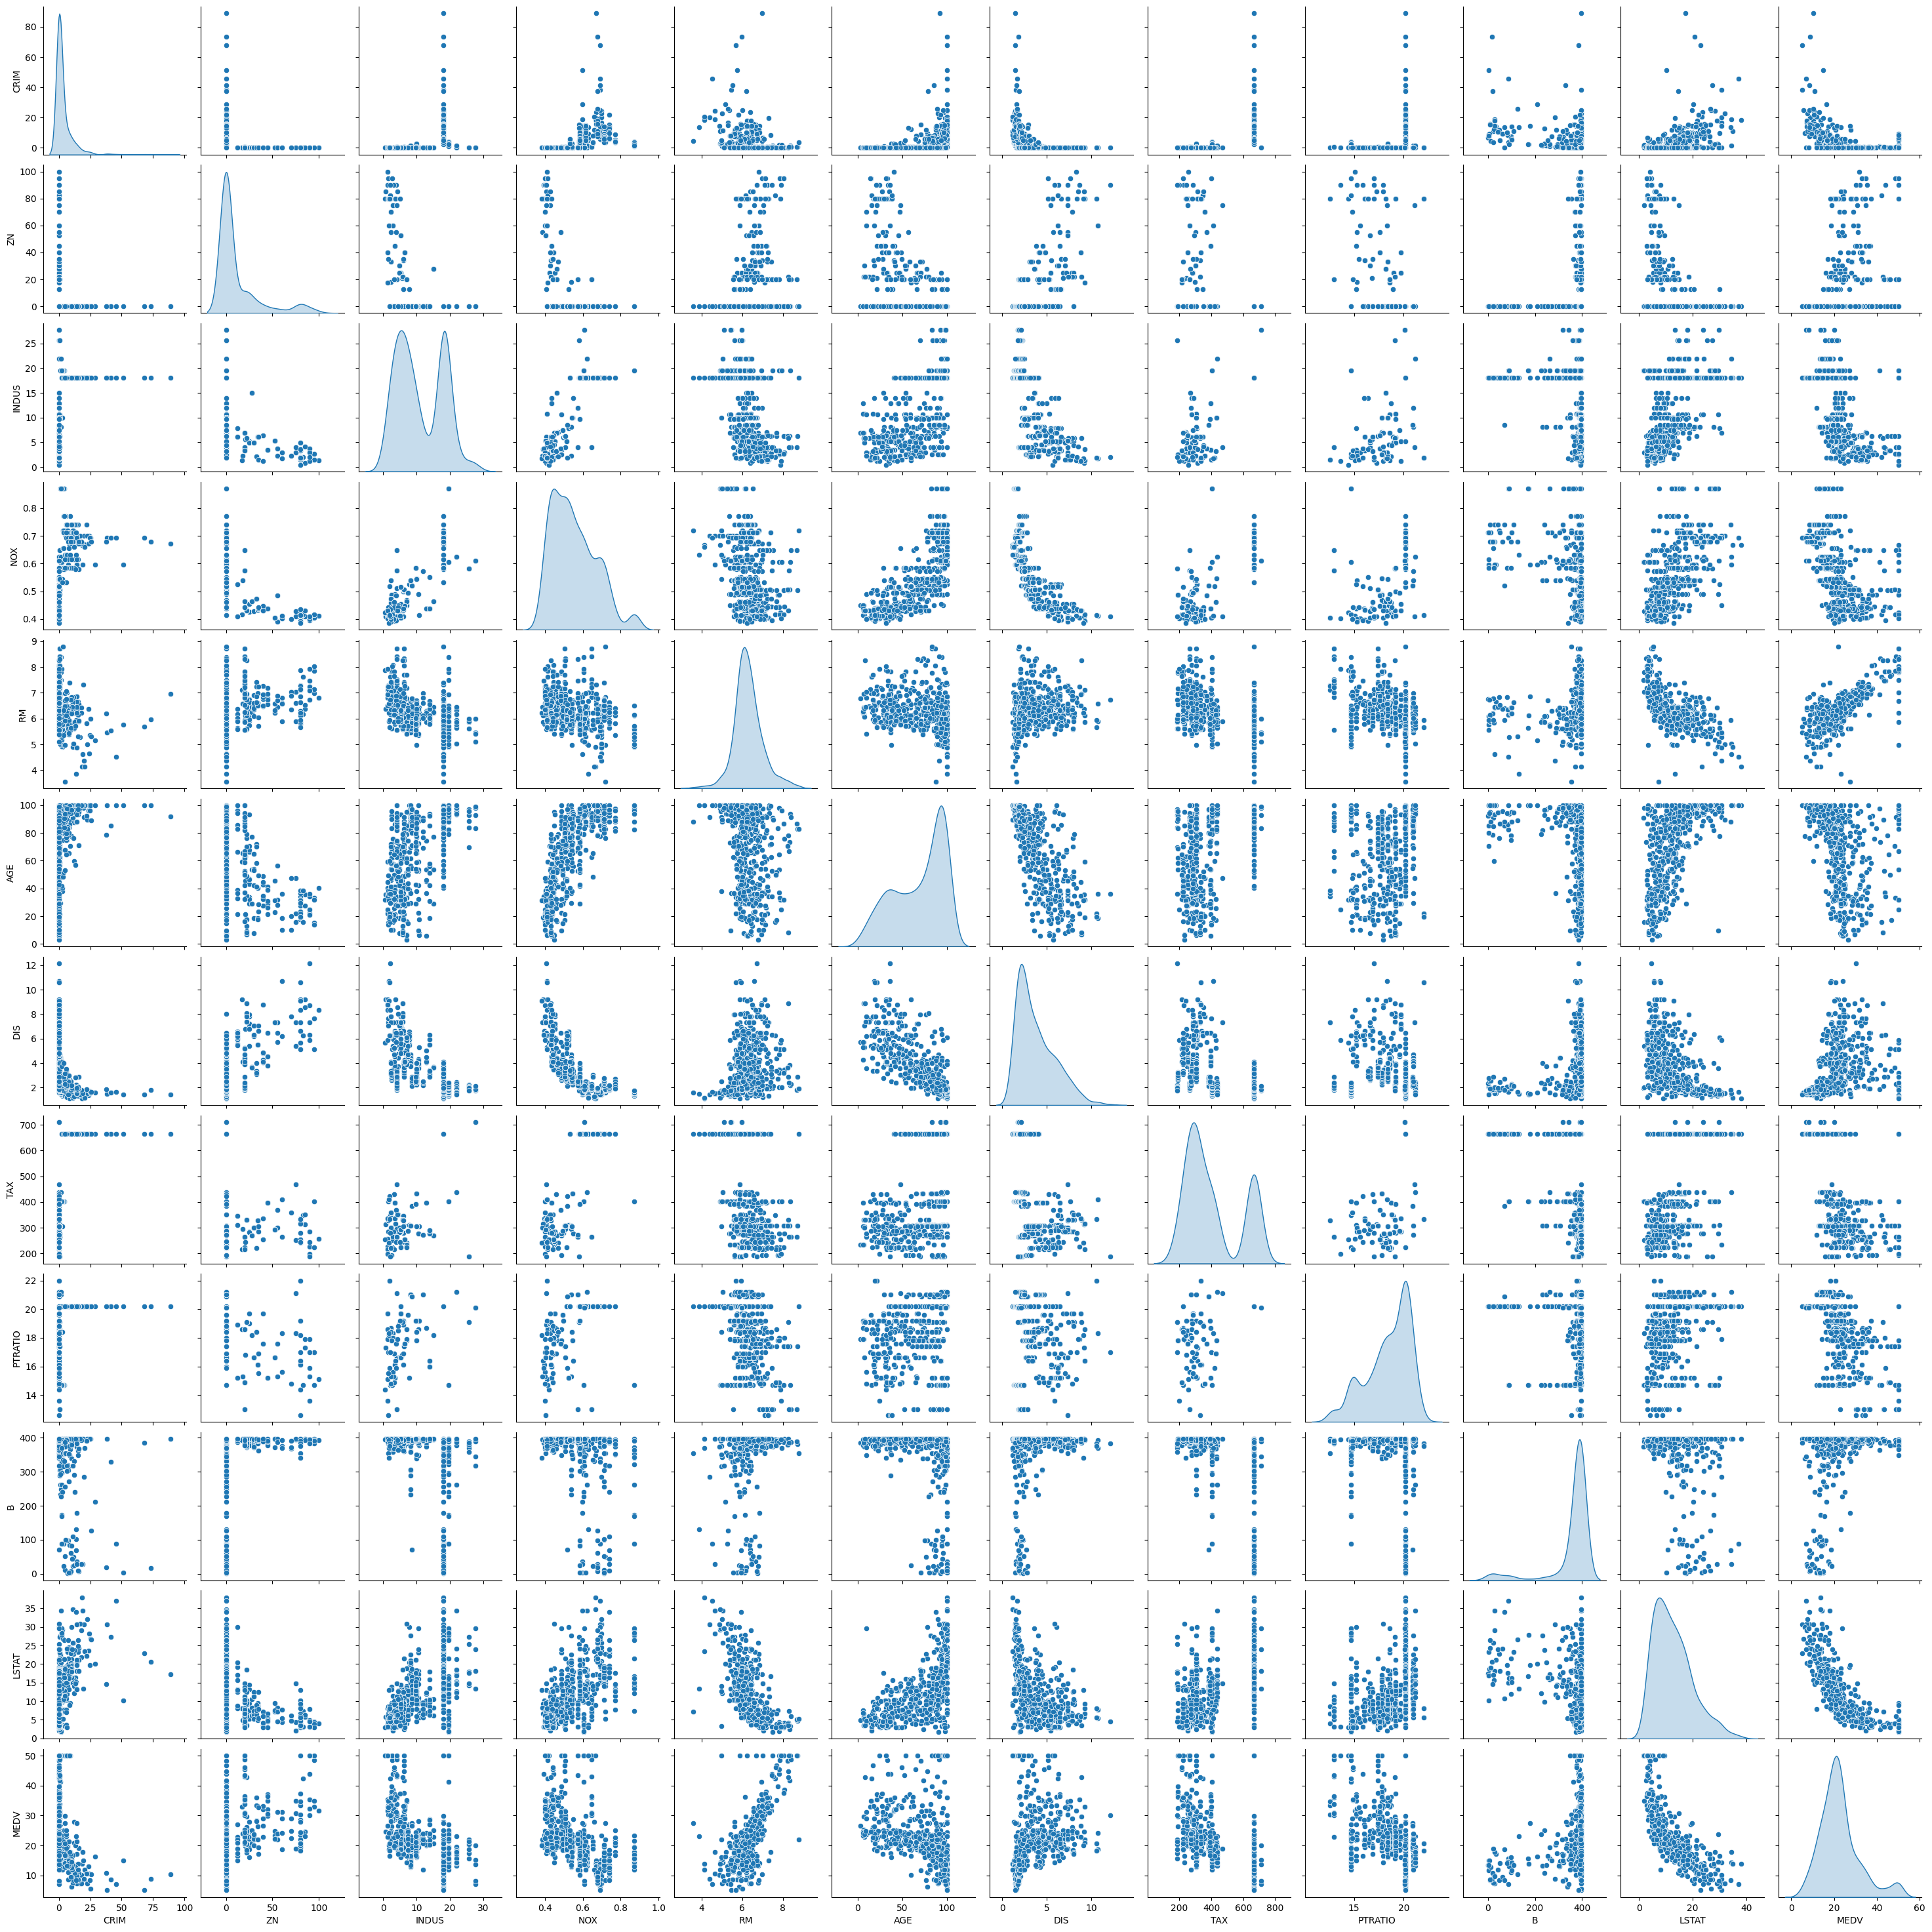

In [20]:
sns.pairplot(df, kind='scatter', diag_kind='kde')
plt.show()

In [21]:
# I Have to apply log transformation on MEDV
df['MEDV'] = np.log(df['MEDV'])
df['MEDV']

0      3.178054
1      3.072693
2      3.546740
3      3.508556
4      3.589059
         ...   
501    3.109061
502    3.025291
503    3.173878
504    3.091042
505    2.476538
Name: MEDV, Length: 506, dtype: float64

In [22]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower_bound, upper_bound)
        #clip() means:

        #Do not allow values to go below a minimum or above a maximum.

        #It cuts extreme values and brings them inside a fixed range.
        # df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

        #Means:

        #If value < lower_bound → make it equal to lower_bound

        #If value > upper_bound → make it equal to upper_bound

        #Otherwise → keep original value
        #No rows are deleted.

        #Why It Is Useful

        #Instead of removing many rows (like 564 → 302),
        #you keep all rows but control extreme values.

        #One Line

        #clip() = “Limit values inside a safe range without deleting data.”

    return df

#how to remove those columns outliers
outlier_col=['CRIM','ZN','INDUS','RM','DIS','PTRATIO','B','LSTAT']

#appliying functions
df_clean=remove_outliers(df,outlier_col)

#shape of the data
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)


Original shape: (506, 14)
Cleaned shape: (506, 14)


<Axes: >

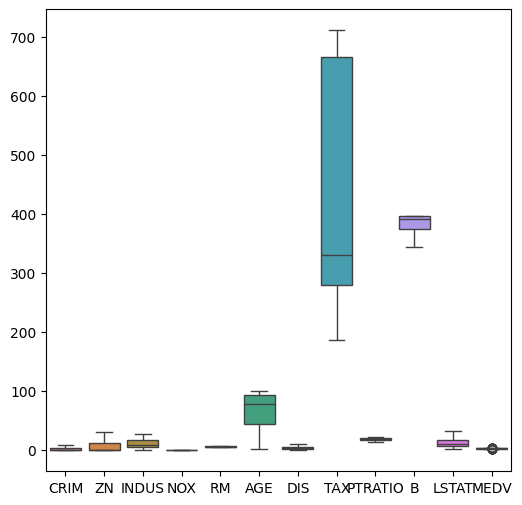

In [23]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df_clean)

# Important inference
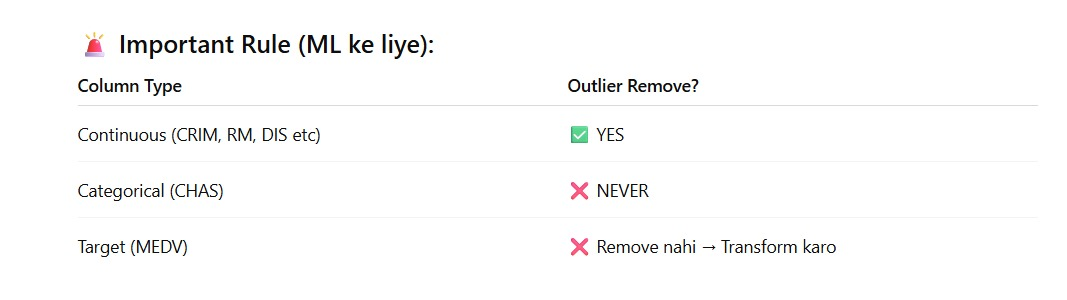

🔥 Tumhe kya karna hai?

Step 1: Categorical hatao outlier removal se

num_cols = ['CRIM','ZN','RM','DIS','PTRATIO','B','LSTAT']

🚫 CHAS ko include mat karo

Step 2: Target pe log apply karo (MEDV)

df['MEDV'] = np.log(df['MEDV'])

Isse target ke outliers handle ho jayenge ✔️

Remove karne ki zarurat nahi

🎯 Final funda:

Categorical me outlier nahi hota

Continuous me hota hai

Target ko transform karo, delete nahi

In [23]:
df_clean['MEDV']=np.log(df_clean['MEDV'])
df_clean['MEDV']

0      1.156269
1      1.122554
2      1.266029
3      1.255205
4      1.277890
         ...   
501    1.134321
502    1.107007
503    1.154954
504    1.128508
505    0.906862
Name: MEDV, Length: 506, dtype: float64

In [24]:
df_clean

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,1.156269
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,1.122554
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,1.266029
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,1.255205
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,1.277890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,1.134321
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,1.107007
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,1.154954
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,1.128508


In [25]:
#feature and target seperate kro
x=df_clean.drop('MEDV',axis=1)
y=df_clean['MEDV']
#Model ko kabhi bhi target variable training me input ke roop me nahi dena chahiye
#Isliye MEDV ko X se hata diya ✔--


In [26]:
#checking if multicollinity is present aur not
# Ensure numeric only
x = x.select_dtypes(include=[np.number])

# Remove inf and NaN
x = x.replace([np.inf, -np.inf], np.nan)
x = x.dropna()

# Convert to float
x = x.astype(float)

# VIF calculation
vif_data = pd.DataFrame()
vif_data["Feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i)
                   for i in range(x.shape[1])]

print(vif_data)

    Feature         VIF
0      CRIM    7.285007
1        ZN    3.245815
2     INDUS   13.894179
3       NOX   85.434296
4        RM  145.306180
5       AGE   21.459828
6       DIS   16.233365
7       TAX   39.313012
8   PTRATIO  120.412741
9         B  283.285835
10    LSTAT   12.265891


In [27]:
#TRAIN/TEST SPLIT
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3,random_state=42)
#👉 Dataset ko training (sikhane) aur testing (performance check karne) ke liye 2 parts me divide karna taaki model unseen data pe bhi achha predict kare.
#training - 70%
#testing - 30%
#test_size=0.3 -> 30% data testing ke liye
#random_state=42 -> har baar same split milega



In [28]:
#scalling very important
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
#👉 Features ko same scale (range) par laana taaki koi ek feature model par haavi na ho jaaye.
#fit_transform() - training data par calculate karke apply karna(mean,std)
#transform() - testing data par sirf apply karna (wahi mean/std use karke)
#🧠 Yeh kya kar raha hai?
#👉 Tumhare saare input features ko same scale pe laa raha hai
#👉 Example: Ek feature 1-1000 range mein hai, doosra 0-1 mein → scaling sabko same range mein laata hai
#👉 Isse model har feature ko equal importance deta hai


In [29]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# Explainiation of the above code

1️⃣ PolynomialFeatures(degree=2, include_bias=False)

This creates an object that will:

Add squared features

Add interaction features
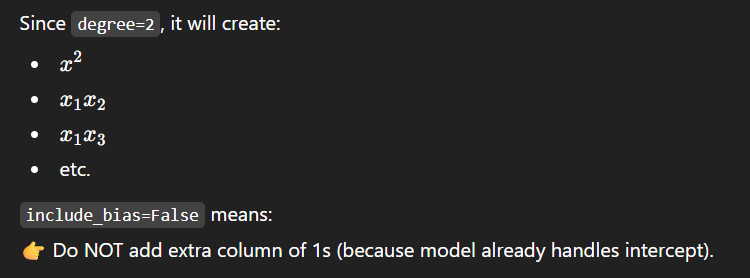

2️⃣ x_train_poly = poly.fit_transform(x_train)

Two things happen here:

(A) fit

It learns how many features exist and how to generate combinations.

(B) transform

It actually creates new polynomial features.

Example:

If original features:

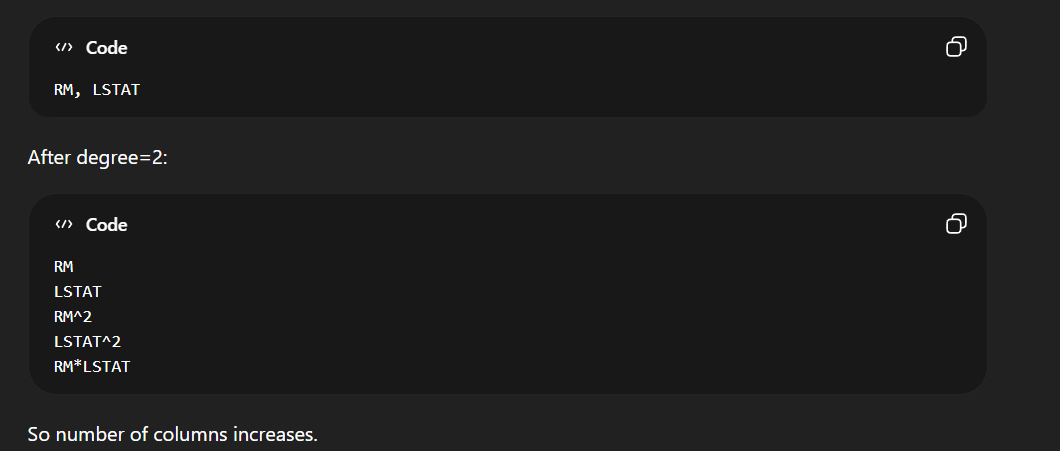

3️⃣ x_test_poly = poly.transform(x_test)

Important difference:

We only use transform() on test data.

Why?

Because:

We already learned structure from training data.

We must apply same transformation to test data.

Never use fit_transform() on test data.

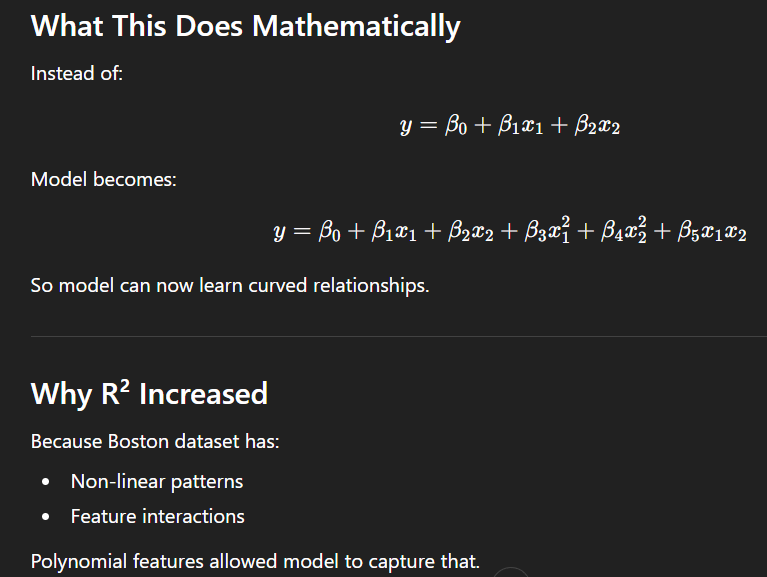



In [37]:
from sklearn.linear_model import Ridge

#This imports Ridge Regression.
#Ridge = Linear Regression + L2 regularization (penalty term).

ridge = Ridge(alpha=20)   # start with 5
# Here:

# alpha = regularization strength

# Larger alpha → stronger penalty

# Smaller alpha → behaves like normal Linear Regression

# In your tuning, alpha=20 gave best R².
ridge.fit(x_train_poly, y_train)
# This means:

# Use polynomial features (x_train_poly)

# Learn coefficients


# Convert back to original scale
y_pred_original = np.exp(y_pred_log)
y_test_original = np.exp(y_test)


In [67]:
# for a in [0.1, 1, 5, 10, 20, 50]:
#     model = Ridge(alpha=a)
#     model.fit(x_train_poly, y_train)
#     y_pred_log = model.predict(x_test_poly)
#     y_pred = np.exp(y_pred_log)
#     print("Alpha:", a, "R2:", r2_score(np.exp(y_test), y_pred))

In [71]:
#model training
# model=LinearRegression()
# model.fit(x_train,y_train)
#👉 Yeh model ko sikha raha hai ki x_train ke features se y_train ko kaise predict karna hai
#👉 Yeh coefficients (slopes) aur intercept calculate karta hai
#🧠 Yeh kya kar raha hai?
# Yeh model ko train kar raha hai using X_train aur y_train
# Yeh best fit line ke liye coefficients aur intercept calculate karta hai
# Taaki unseen data (X_test) par target value predict kar sake

In [36]:
#Prediction
y_pred_log = ridge.predict(x_test_poly)
#👉 Yeh trained model ko use karke X_test ke liye predicted values calculate karta hai
#🧠 Yeh kya kar raha hai?
# Yeh model ke coefficients aur intercept ko X_test features par apply karta hai
# Formula: y_pred = (coef1 * x1) + (coef2 * x2) + ... + intercept
# Har row ke liye separate prediction generate karta hai

In [38]:
#Evaluation
r2=r2_score(y_test_original,y_pred_original)
mse=mean_squared_error(y_test_original,y_pred_original)
rmse=np.sqrt(mse)

# r2_ridge=r2_score(y_test_actual,ridge_pred)
# mse_ridge=mean_squared_error(y_test_actual,ridge_pred)
# rmse_ridge=np.sqrt(mse_ridge)
print(f'R2 Score:{r2:.2f}')
print(f'MSE:{mse:.2f}')
print(f'RMSE:{rmse:.2f}')

# print(f'R2 Score:{r2_ridge:.2f}')
# print(f'MSE:{mse_ridge:.2f}')
# print(f'RMSE:{rmse_ridge:.2f}')
#👉 Yeh kya kar raha hai?
# Yeh model ke performance ko evaluate kar raha hai
# R2 Score: Yeh batata hai ki model kitna variance explain kar raha hai
# RMSE: Yeh batata hai ki model kitna error kar raha hai


R2 Score:0.80
MSE:0.03
RMSE:0.18


In [ ]:
# y_test_actual = np.exp(y_test)
# y_pred_actual = np.exp(y_pred)
#np.exp() log-transformed target ko wapas original scale mein convert karta hai taaki real-value error calculate kiya ja sake.

In [33]:
y_pred_original = np.exp(y_pred_log)
y_test_original = np.exp(y_test)

In [79]:
y_test_original = np.exp(y_test).flatten()
y_pred_original = np.exp(y_pred_log).flatten()

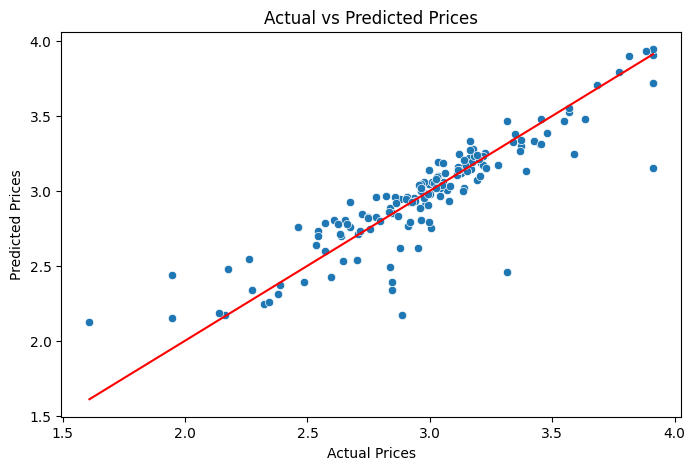

In [47]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test_original, y=y_pred_original)
plt.plot([min(y_test_original), max(y_test_original)], [min(y_test_original), max(y_test_original)], color='red')  # perfect line
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()